# 07 Text Content Indicator Construction



In [1]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 180)

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / 'data'
CORPUS_DIR = DATA_DIR / 'corpus'
INDICATORS_DIR = DATA_DIR / 'indicators'
FIGURES_DIR = PROJECT_ROOT / 'figures' / '07_notebook_figures'

INDICATORS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

MASTER_PARQUET = CORPUS_DIR / 'master_articles.parquet'
MASTER_CSV = CORPUS_DIR / 'master_articles_light.csv'

ARTICLE_OUT_CSV = INDICATORS_DIR / 'article_text_content_indicators.csv'
ARTICLE_OUT_PARQUET = INDICATORS_DIR / 'article_text_content_indicators.parquet'
MONTHLY_OUT_CSV = INDICATORS_DIR / 'monthly_text_content_indicators.csv'
MONTHLY_OUT_PARQUET = INDICATORS_DIR / 'monthly_text_content_indicators.parquet'
EVENT_SUMMARY_OUT_CSV = INDICATORS_DIR / 'text_indicator_event_window_summary.csv'

SHOCKS = {
    'Cologne': pd.Timestamp('2016-01-01'),
    'Chemnitz': pd.Timestamp('2018-08-01'),
    'Correctiv': pd.Timestamp('2024-01-01'),
}

In [2]:
def load_master() -> pd.DataFrame:
    if MASTER_PARQUET.exists():
        return pd.read_parquet(MASTER_PARQUET)
    if MASTER_CSV.exists():
        return pd.read_csv(MASTER_CSV)
    raise FileNotFoundError(f'Missing master corpus file: {MASTER_PARQUET} and {MASTER_CSV}')

master = load_master().copy()

required_input_cols = ['keep_drop_review', 'date', 'month', 'article_id', 'text_body']
missing_input = [c for c in required_input_cols if c not in master.columns]
if missing_input:
    raise ValueError(f'Master corpus missing required columns: {missing_input}')

kept = master[master['keep_drop_review'].astype(str).str.lower() == 'keep'].copy()
if kept.empty:
    raise ValueError('Kept corpus is empty after keep_drop_review filter.')

if kept['article_id'].isna().any():
    raise ValueError('article_id has missing values in kept corpus.')
if kept['article_id'].duplicated().any():
    dupes = kept.loc[kept['article_id'].duplicated(), 'article_id'].head(10).tolist()
    raise ValueError(f'Found duplicate article_id values in kept corpus: {dupes}')

kept['date'] = pd.to_datetime(kept['date'], errors='coerce')
if kept['date'].isna().any():
    raise ValueError('Date parsing failed for some kept articles.')

kept['month_dt'] = kept['date'].dt.to_period('M').dt.to_timestamp()
kept['year_month'] = kept['month_dt'].dt.strftime('%Y-%m')
kept['year'] = kept['month_dt'].dt.year
kept['month_num'] = kept['month_dt'].dt.month

if kept['text_body'].fillna('').str.strip().eq('').mean() > 0.1:
    raise ValueError('More than 10% of kept articles have empty text_body.')

In [3]:
GERMAN_CHAR_MAP = str.maketrans({
    "ä": "ae", "ö": "oe", "ü": "ue", "ß": "ss",
    "Ä": "ae", "Ö": "oe", "Ü": "ue",
})

def normalize_german_ascii(text: str) -> str:
    if text is None:
        return ''
    s = str(text).translate(GERMAN_CHAR_MAP).lower()
    s = re.sub(r'[^a-z0-9\s]', ' ', s)
    s = re.sub(r'\s+', ' ', s).strip()
    return s

_umlaut_probe = normalize_german_ascii('Flüchtlinge äußern größere Sorge über Abschiebung')
assert 'fluechtlinge' in _umlaut_probe
assert 'aeussern' in _umlaut_probe
assert 'groessere' in _umlaut_probe
assert 'ueber' in _umlaut_probe
assert 'auslaender' in normalize_german_ascii('Ausländer')
assert 'uebergriff' in normalize_german_ascii('Übergriff')

DICTIONARY_PATH = PROJECT_ROOT / 'data' / 'dictionaries' / 'text_indicator_term_patterns.json'
if not DICTIONARY_PATH.exists():
    raise FileNotFoundError(f'Missing dictionary file: {DICTIONARY_PATH}')

with DICTIONARY_PATH.open('r', encoding='utf-8') as f:
    DICTIONARY_CONFIG = json.load(f)

TERM_GROUPS = DICTIONARY_CONFIG.get('groups', {})
TERM_PATTERNS = {k: v.get('patterns', []) for k, v in TERM_GROUPS.items()}

if not TERM_PATTERNS:
    raise ValueError('Dictionary file loaded but TERM_PATTERNS is empty')
for group, pats in TERM_PATTERNS.items():
    if not isinstance(pats, list) or not pats:
        raise ValueError(f'Dictionary group {group} has no patterns')

COMPILED = {k: re.compile('|'.join(v)) for k, v in TERM_PATTERNS.items()}

def count_group_terms(norm_text: str) -> dict:
    out = {}
    for group, patt in COMPILED.items():
        out[f'{group}_terms_count'] = len(patt.findall(norm_text))
    return out

kept['text_normalized'] = kept['text_body'].fillna('').map(normalize_german_ascii)
kept['text_token_count'] = kept['text_normalized'].str.split().map(len)

wc = pd.to_numeric(kept.get('word_count', np.nan), errors='coerce')
kept['word_count_used'] = wc.where(wc > 0, kept['text_token_count'])
kept['word_count_used'] = kept['word_count_used'].fillna(kept['text_token_count'])

count_df = kept['text_normalized'].map(count_group_terms).apply(pd.Series)
article = pd.concat([kept, count_df], axis=1)

for group in TERM_PATTERNS.keys():
    c = f'{group}_terms_count'
    p = f'{group}_terms_per_1000_words'
    h = f'has_{group}_terms'
    article[p] = np.where(article['word_count_used'] > 0, article[c] * 1000.0 / article['word_count_used'], np.nan)
    article[h] = (article[c] > 0).astype(int)

article['security_share_of_migration_context'] = np.where(
    article['migration_terms_count'] > 0,
    article['security_terms_count'] / article['migration_terms_count'],
    np.nan,
)
article['afd_mentions_binary'] = article['has_afd_far_right_terms']
article['remigration_democracy_binary'] = article['has_remigration_democracy_terms']
article['negative_threat_intensity'] = article['negative_threat_terms_per_1000_words']

all_term_sum = article[[f'{g}_terms_count' for g in TERM_PATTERNS.keys()]].sum().sum()
if all_term_sum == 0:
    raise ValueError('All text indicator term counts are zero. Dictionary likely failed.')

base_cols = [
    'article_id', 'date', 'year_month', 'month_dt', 'year', 'month_num',
    'publication', 'publication_normalized', 'word_count', 'body_char_count', 'word_count_used',
    'corpus_type', 'corpus_name', 'batch_id', 'source_archive'
]
existing_base = [c for c in base_cols if c in article.columns]

indicator_cols = []
for g in TERM_PATTERNS.keys():
    indicator_cols.extend([
        f'{g}_terms_count',
        f'{g}_terms_per_1000_words',
        f'has_{g}_terms',
    ])
indicator_cols.extend([
    'security_share_of_migration_context',
    'afd_mentions_binary',
    'remigration_democracy_binary',
    'negative_threat_intensity',
])

article_out = article[existing_base + indicator_cols].copy()
article_out = article_out.sort_values(['month_dt', 'article_id']).reset_index(drop=True)

if len(article_out) != len(kept):
    raise ValueError(f'Article output row count mismatch: {len(article_out)} vs kept {len(kept)}')

for c in [col for col in article_out.columns if col.endswith('_per_1000_words')]:
    bad = (~np.isfinite(article_out[c])) & article_out[c].notna()
    if bad.any():
        raise ValueError(f'Found non-finite values in {c}')

article_out.to_csv(ARTICLE_OUT_CSV, index=False)
article_out.to_parquet(ARTICLE_OUT_PARQUET, index=False)

for g in TERM_PATTERNS.keys():
    print(g, int(article_out[f'{g}_terms_count'].sum()))

migration 139631
security 25842
afd_far_right 11942
remigration_democracy 6319
negative_threat 24645


In [4]:
agg_dict = {
    'month_dt': ('month_dt', 'first'),
    'year': ('year', 'first'),
    'month_num': ('month_num', 'first'),
    'n_articles_text_indicators': ('article_id', 'size'),
    'mean_word_count': ('word_count_used', 'mean'),
    'median_word_count': ('word_count_used', 'median'),
    'total_word_count': ('word_count_used', 'sum'),
    'security_share_of_migration_context_mean': ('security_share_of_migration_context', 'mean'),
}

for g in TERM_PATTERNS.keys():
    agg_dict[f'{g}_terms_per_1000_mean'] = (f'{g}_terms_per_1000_words', 'mean')
    agg_dict[f'{g}_terms_per_1000_median'] = (f'{g}_terms_per_1000_words', 'median')
    agg_dict[f'share_articles_with_{g}_terms'] = (f'has_{g}_terms', 'mean')
    agg_dict[f'{g}_terms_total'] = (f'{g}_terms_count', 'sum')

monthly = article_out.groupby('year_month', as_index=False).agg(**agg_dict)
monthly = monthly.sort_values('month_dt').reset_index(drop=True)

expected_range = pd.period_range('2013-01', '2025-12', freq='M')
actual_range = pd.PeriodIndex(monthly['month_dt'].dt.to_period('M').unique(), freq='M')
missing_months_before_fill = expected_range.difference(actual_range)

full_months = pd.DataFrame({'year_month': expected_range.strftime('%Y-%m')})
full_months['month_dt'] = expected_range.to_timestamp()
full_months['year'] = full_months['month_dt'].dt.year
full_months['month_num'] = full_months['month_dt'].dt.month

monthly_out = full_months.merge(monthly.drop(columns=['month_dt', 'year', 'month_num'], errors='ignore'), on='year_month', how='left')
monthly_out['month'] = monthly_out['year_month']

zero_fill_cols = ['n_articles_text_indicators', 'total_word_count'] + [f'{g}_terms_total' for g in TERM_PATTERNS.keys()]
for col in zero_fill_cols:
    if col in monthly_out.columns:
        monthly_out[col] = monthly_out[col].fillna(0)

for col in ['n_articles_text_indicators', 'total_word_count'] + [f'{g}_terms_total' for g in TERM_PATTERNS.keys()]:
    if col in monthly_out.columns:
        monthly_out[col] = monthly_out[col].astype(int)

monthly_out['text_indicator_month_has_articles'] = monthly_out['n_articles_text_indicators'] > 0

front_cols = [
    'month', 'year_month', 'month_dt', 'year', 'month_num',
    'text_indicator_month_has_articles',
    'n_articles_text_indicators', 'mean_word_count', 'median_word_count', 'total_word_count',
    'migration_terms_per_1000_mean', 'migration_terms_total', 'share_articles_with_migration_terms',
    'security_terms_per_1000_mean', 'security_terms_total', 'share_articles_with_security_terms',
    'afd_far_right_terms_per_1000_mean', 'afd_far_right_terms_total', 'share_articles_with_afd_far_right_terms',
    'remigration_democracy_terms_per_1000_mean', 'remigration_democracy_terms_total', 'share_articles_with_remigration_democracy_terms',
    'negative_threat_terms_per_1000_mean', 'negative_threat_terms_total', 'share_articles_with_negative_threat_terms',
    'security_share_of_migration_context_mean',
]
existing_front = [c for c in front_cols if c in monthly_out.columns]
other_cols = [c for c in monthly_out.columns if c not in existing_front]
monthly_out = monthly_out[existing_front + other_cols].copy()
monthly_out = monthly_out.sort_values('month_dt').reset_index(drop=True)

if monthly_out['year_month'].duplicated().any():
    raise ValueError('Monthly indicators have duplicate months.')
if len(monthly_out) != len(expected_range):
    raise ValueError(f'Monthly output length mismatch: {len(monthly_out)} vs expected {len(expected_range)}')

missing_months_after_fill = expected_range.difference(pd.PeriodIndex(monthly_out['month_dt'].dt.to_period('M').unique(), freq='M'))
if len(missing_months_after_fill) > 0:
    raise ValueError(f'Monthly output still missing months after fill: {[m.strftime("%Y-%m") for m in missing_months_after_fill]}')

monthly_out.to_csv(MONTHLY_OUT_CSV, index=False)
monthly_out.to_parquet(MONTHLY_OUT_PARQUET, index=False)


check_cols = [
    'year_month', 'n_articles_text_indicators',
    'migration_terms_per_1000_mean', 'security_terms_per_1000_mean',
    'afd_far_right_terms_per_1000_mean', 'remigration_democracy_terms_per_1000_mean',
    'negative_threat_terms_per_1000_mean', 'text_indicator_month_has_articles',
]
check_cols = [c for c in check_cols if c in monthly_out.columns]

ids_201908 = set(article_out.loc[article_out['year_month'] == '2019-08', 'article_id'])
ids_201909 = set(article_out.loc[article_out['year_month'] == '2019-09', 'article_id'])
assert len(ids_201909) > 0, '2019-09 has no article indicators after refresh'
assert ids_201908 != ids_201909, '2019-09 article IDs are identical to 2019-08; possible duplicate archive issue remains'

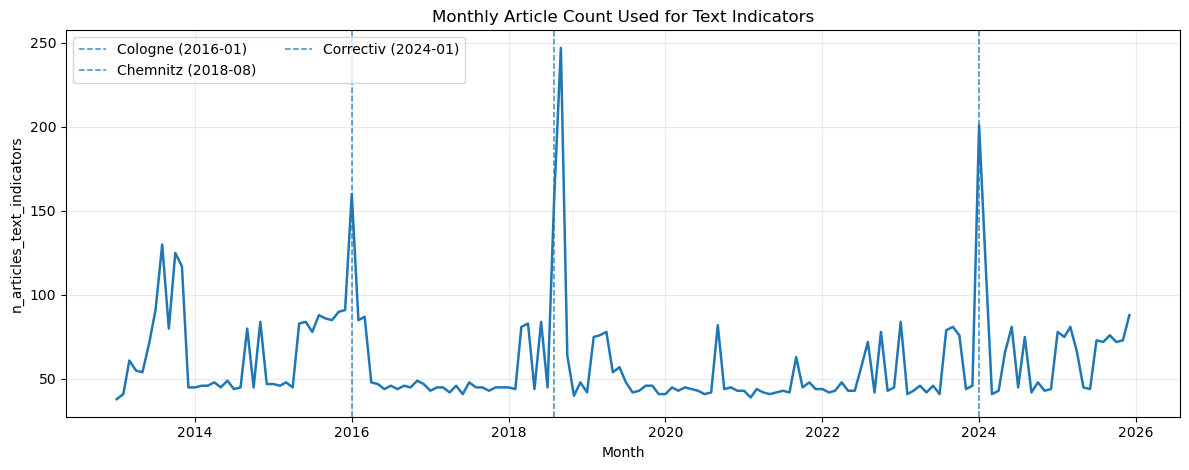

Saved: c:\PythonProjects\AfD-project\figures\07_notebook_figures\monthly_n_articles_text_indicators.png


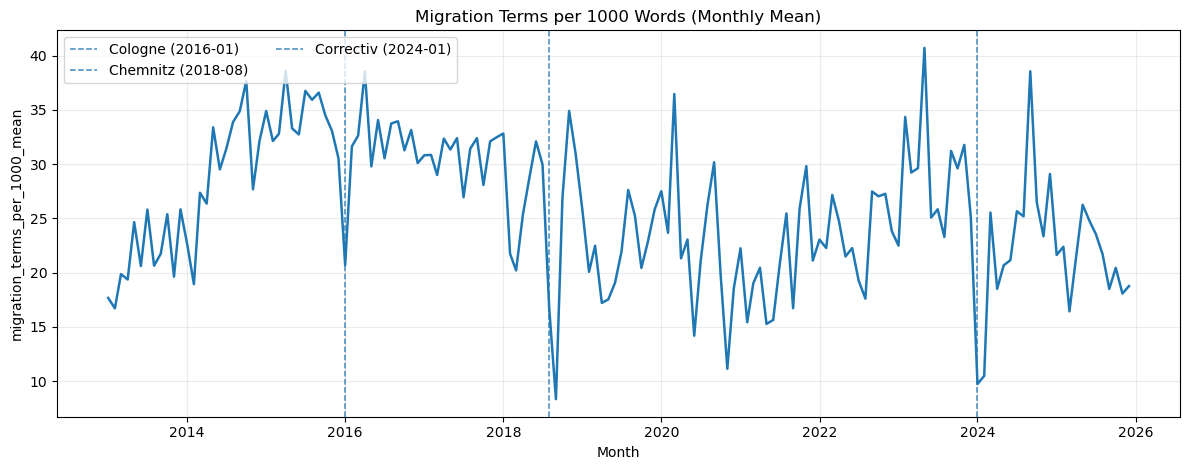

Saved: c:\PythonProjects\AfD-project\figures\07_notebook_figures\monthly_migration_terms_per_1000_mean.png


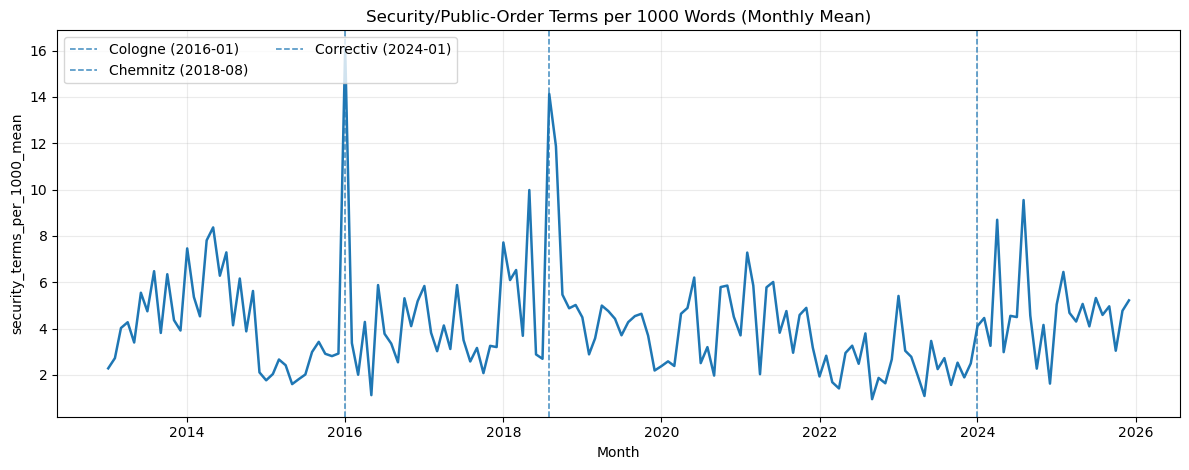

Saved: c:\PythonProjects\AfD-project\figures\07_notebook_figures\monthly_security_terms_per_1000_mean.png


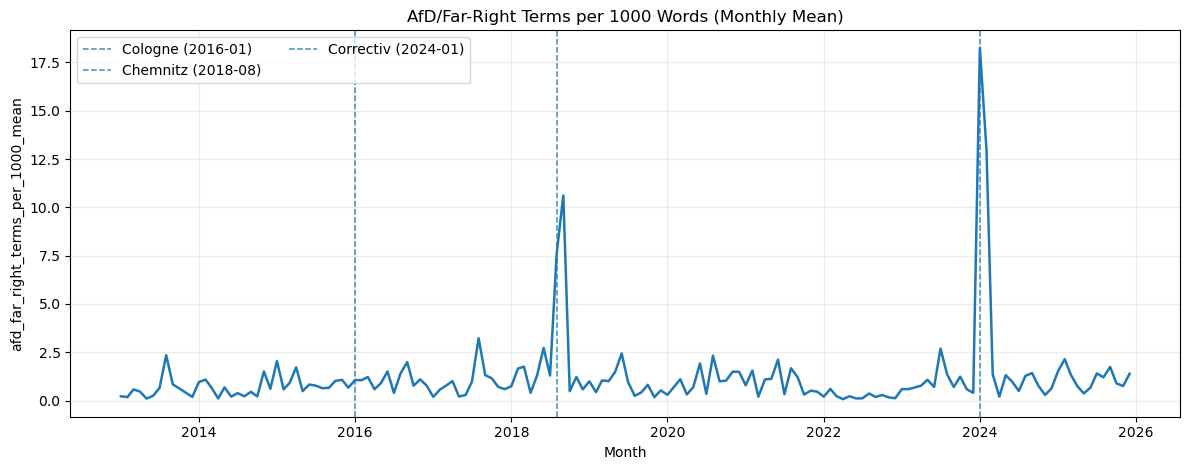

Saved: c:\PythonProjects\AfD-project\figures\07_notebook_figures\monthly_afd_far_right_terms_per_1000_mean.png


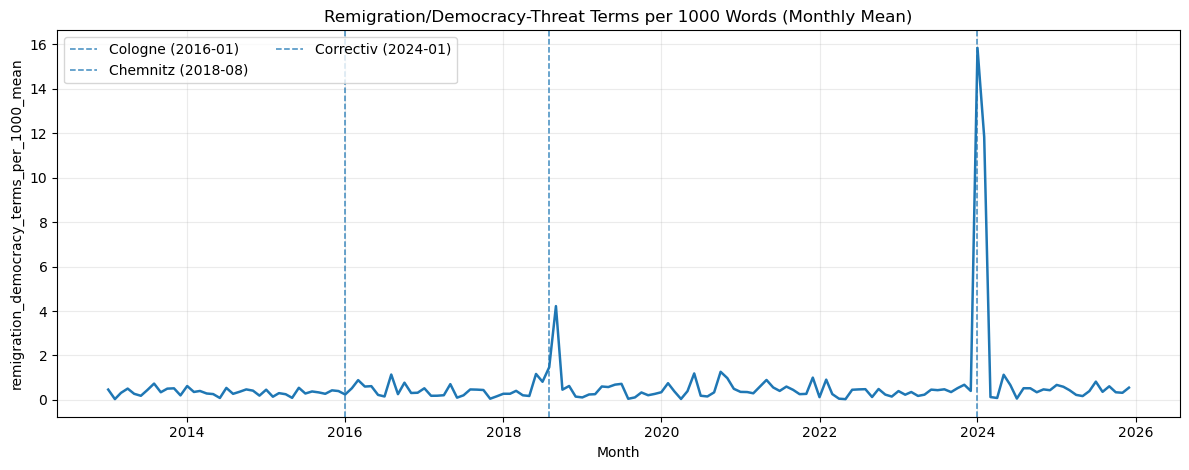

Saved: c:\PythonProjects\AfD-project\figures\07_notebook_figures\monthly_remigration_democracy_terms_per_1000_mean.png


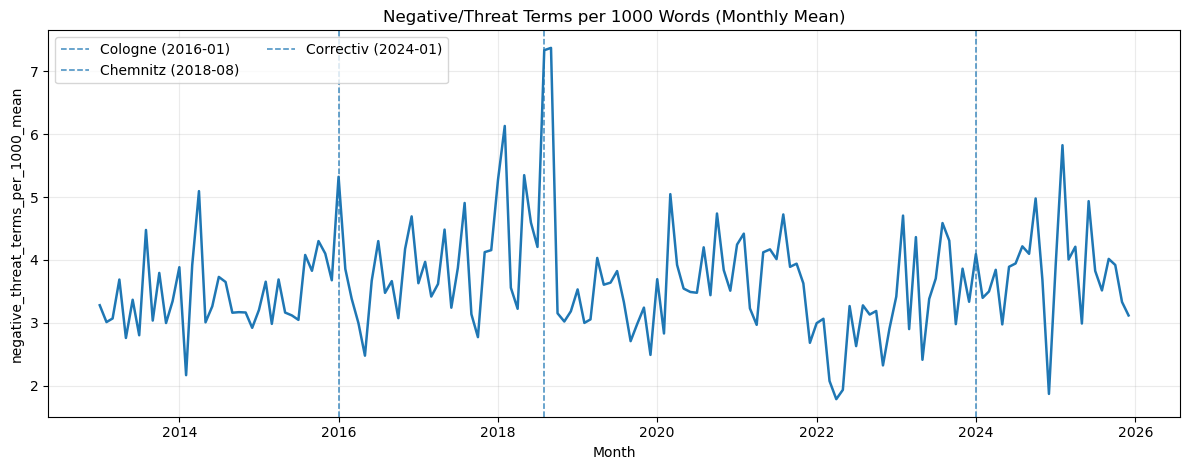

Saved: c:\PythonProjects\AfD-project\figures\07_notebook_figures\monthly_negative_threat_terms_per_1000_mean.png


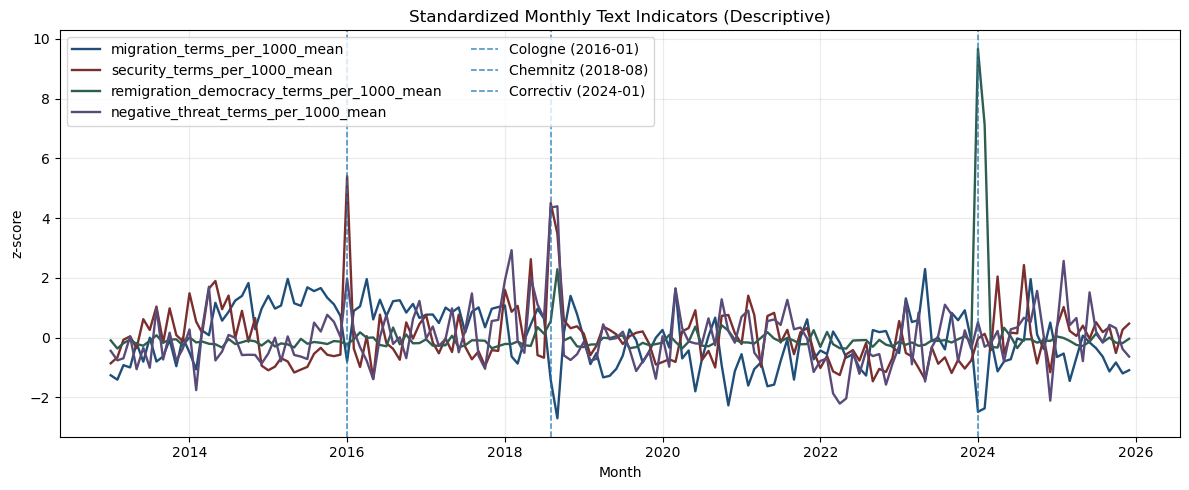

In [5]:
def add_shock_lines(ax):
    for label, dt in SHOCKS.items():
        ax.axvline(dt, linestyle='--', linewidth=1.1, alpha=0.85, label=f'{label} ({dt.strftime("%Y-%m")})')

plot_specs = [
    ('n_articles_text_indicators', 'Monthly Article Count Used for Text Indicators', 'n_articles_text_indicators', 'monthly_n_articles_text_indicators.png'),
    ('migration_terms_per_1000_mean', 'Migration Terms per 1000 Words (Monthly Mean)', 'migration_terms_per_1000_mean', 'monthly_migration_terms_per_1000_mean.png'),
    ('security_terms_per_1000_mean', 'Security/Public-Order Terms per 1000 Words (Monthly Mean)', 'security_terms_per_1000_mean', 'monthly_security_terms_per_1000_mean.png'),
    ('afd_far_right_terms_per_1000_mean', 'AfD/Far-Right Terms per 1000 Words (Monthly Mean)', 'afd_far_right_terms_per_1000_mean', 'monthly_afd_far_right_terms_per_1000_mean.png'),
    ('remigration_democracy_terms_per_1000_mean', 'Remigration/Democracy-Threat Terms per 1000 Words (Monthly Mean)', 'remigration_democracy_terms_per_1000_mean', 'monthly_remigration_democracy_terms_per_1000_mean.png'),
    ('negative_threat_terms_per_1000_mean', 'Negative/Threat Terms per 1000 Words (Monthly Mean)', 'negative_threat_terms_per_1000_mean', 'monthly_negative_threat_terms_per_1000_mean.png'),
]

for col, title, ylab, fname in plot_specs:
    fig, ax = plt.subplots(figsize=(12, 4.8))
    ax.plot(monthly_out['month_dt'], monthly_out[col], linewidth=1.8)
    add_shock_lines(ax)
    ax.set_title(title)
    ax.set_xlabel('Month')
    ax.set_ylabel(ylab)
    ax.grid(alpha=0.25)
    ax.legend(loc='upper left', ncol=2)
    fig.tight_layout()
    out = FIGURES_DIR / fname
    fig.savefig(out, dpi=150)
    plt.show()
    print('Saved:', out)

                                      
std_cols = [
    'migration_terms_per_1000_mean',
    'security_terms_per_1000_mean',
    'remigration_democracy_terms_per_1000_mean',
    'negative_threat_terms_per_1000_mean',
]

std_df = monthly_out[['month_dt'] + std_cols].copy()
for c in std_cols:
    s = pd.to_numeric(std_df[c], errors='coerce')
    std_df[c + '_z'] = (s - s.mean()) / (s.std(ddof=0) if s.std(ddof=0) != 0 else 1.0)

fig, ax = plt.subplots(figsize=(12, 5))
for c, color in zip(std_cols, ['#1f4e79','#7a2e2e','#2f5d50','#5a4a78']):
    ax.plot(std_df['month_dt'], std_df[c + '_z'], linewidth=1.7, label=c, color=color)
add_shock_lines(ax)
ax.set_title('Standardized Monthly Text Indicators (Descriptive)')
ax.set_xlabel('Month')
ax.set_ylabel('z-score')
ax.grid(alpha=0.25)
ax.legend(loc='upper left', ncol=2)
fig.tight_layout()
out = FIGURES_DIR / 'combined_standardized_text_indicators.png'
fig.savefig(out, dpi=150)
plt.show()

In [6]:
selected_cols = [
    'n_articles_text_indicators',
    'migration_terms_per_1000_mean',
    'security_terms_per_1000_mean',
    'afd_far_right_terms_per_1000_mean',
    'remigration_democracy_terms_per_1000_mean',
    'negative_threat_terms_per_1000_mean',
]

for label, shock_month in SHOCKS.items():
    w = monthly_out[(monthly_out['month_dt'] >= shock_month - pd.DateOffset(months=6)) & (monthly_out['month_dt'] <= shock_month + pd.DateOffset(months=6))].copy()
    w['rel_month'] = ((w['month_dt'].dt.year - shock_month.year) * 12 + (w['month_dt'].dt.month - shock_month.month)).astype(int)
    w = w.sort_values('month_dt')
    print('Shock +/-6:', label, shock_month.strftime('%Y-%m'))
    print(w[['year_month','rel_month'] + selected_cols].to_string(index=False))
    print('')

summary_rows = []
for label, shock_month in SHOCKS.items():
    for win in [3, 6]:
        w = monthly_out[(monthly_out['month_dt'] >= shock_month - pd.DateOffset(months=win)) & (monthly_out['month_dt'] <= shock_month + pd.DateOffset(months=win))].copy()
        w['rel_month'] = ((w['month_dt'].dt.year - shock_month.year) * 12 + (w['month_dt'].dt.month - shock_month.month)).astype(int)
        pre = w[w['rel_month'] < 0]
        post = w[w['rel_month'] > 0]
        shock_row = w[w['rel_month'] == 0]
        for ind in selected_cols:
            summary_rows.append({
                'shock_label': label,
                'shock_month': shock_month.strftime('%Y-%m'),
                'indicator': ind,
                'window_months': win,
                'pre_mean': pre[ind].mean(),
                'post_mean': post[ind].mean(),
                'change_post_minus_pre': post[ind].mean() - pre[ind].mean(),
                'shock_month_value': shock_row[ind].iloc[0] if len(shock_row) == 1 else np.nan,
                'n_months_pre': len(pre),
                'n_months_post': len(post),
            })

event_summary = pd.DataFrame(summary_rows)
event_summary.to_csv(EVENT_SUMMARY_OUT_CSV, index=False)

Shock +/-6: Cologne 2016-01
year_month  rel_month  n_articles_text_indicators  migration_terms_per_1000_mean  security_terms_per_1000_mean  afd_far_right_terms_per_1000_mean  remigration_democracy_terms_per_1000_mean  negative_threat_terms_per_1000_mean
   2015-07         -6                          78                      36.744290                      2.019100                           0.774020                                   0.287608                             3.045782
   2015-08         -5                          88                      35.924009                      2.989692                           0.641663                                   0.380044                             4.079031
   2015-09         -4                          86                      36.582634                      3.428024                           0.661289                                   0.337481                             3.826830
   2015-10         -3                          85                   

In [7]:
                                           
focus_inds = [
    'migration_terms_per_1000_mean',
    'security_terms_per_1000_mean',
    'afd_far_right_terms_per_1000_mean',
    'remigration_democracy_terms_per_1000_mean',
    'negative_threat_terms_per_1000_mean',
]

summary_focus = event_summary[(event_summary['window_months'] == 6) & (event_summary['indicator'].isin(focus_inds))].copy()
summary_focus = summary_focus.sort_values(['shock_label','indicator'])

## Interpretation 

Correctiv can be better reflected in remigration,democracy-threat terms
Chemnitz may be better reflected in security/public-order and far-right indicators
Cologne shows migration/security/negative-threat
